# Dubai Real Estate Price Prediction POC

In [3]:
import pandas as pd
import numpy as np

In [4]:
#Load the dataset with the correct encoding (UTF-8)
try:
    df = pd.read_csv(r"C:\Users\madhu\OneDrive\Desktop\V\DataScience\sample_data.csv", encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(r"C:\Users\madhu\OneDrive\Desktop\V\DataScience\sample_data.csv", encoding='utf-8-sig')

In [5]:
df.head(5)

,Unnamed: 0,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,139669,1-102-2022-15336,102,1,مبايعات,Sales,بيع - تسجيل مبدئى,Sell - Pre registration,13-06-2022,3,...,1 B/R,1,62.81,1233000,19630.63,NaN,NaN,1.0,1.0,0.0
1,788920,1-102-2013-7960,102,1,مبايعات,Sales,بيع - تسجيل مبدئى,Sell - Pre registration,30-09-2013,3,...,Office,1,103.63,539420,5205.25,NaN,NaN,1.0,1.0,0.0
2,729356,1-11-2025-24285,11,1,مبايعات,Sales,بيع,Sell,10-06-2025,3,...,1 B/R,1,56.79,890000,15671.77,NaN,NaN,2.0,1.0,0.0
3,1112915,1-102-2016-4650,102,1,مبايعات,Sales,بيع - تسجيل مبدئى,Sell - Pre registration,28-04-2016,3,...,Studio,1,38.10,454811,11937.32,NaN,NaN,1.0,1.0,0.0
4,47566,1-11-2013-33304,11,1,مبايعات,Sales,بيع,Sell,05-11-2013,3,...,1 B/R,1,97.60,9597888,98339.02,NaN,NaN,1.0,1.0,0.0


In [4]:
# 2. Inspect the first few rows and column names
print("Initial Data Shape:", df.shape)
print(df.head())

Initial Data Shape: (90000, 47)
   Unnamed: 0    transaction_id  procedure_id  trans_group_id trans_group_ar  \
0      139669  1-102-2022-15336           102               1        مبايعات   
1      788920   1-102-2013-7960           102               1        مبايعات   
2      729356   1-11-2025-24285            11               1        مبايعات   
3     1112915   1-102-2016-4650           102               1        مبايعات   
4       47566   1-11-2013-33304            11               1        مبايعات   

  trans_group_en  procedure_name_ar        procedure_name_en instance_date  \
0          Sales  بيع - تسجيل مبدئى  Sell - Pre registration    13-06-2022   
1          Sales  بيع - تسجيل مبدئى  Sell - Pre registration    30-09-2013   
2          Sales                بيع                     Sell    10-06-2025   
3          Sales  بيع - تسجيل مبدئى  Sell - Pre registration    28-04-2016   
4          Sales                بيع                     Sell    05-11-2013   

   property_type_i

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            90000 non-null  int64  
 1   transaction_id        90000 non-null  object 
 2   procedure_id          90000 non-null  int64  
 3   trans_group_id        90000 non-null  int64  
 4   trans_group_ar        90000 non-null  object 
 5   trans_group_en        90000 non-null  object 
 6   procedure_name_ar     90000 non-null  object 
 7   procedure_name_en     90000 non-null  object 
 8   instance_date         90000 non-null  object 
 9   property_type_id      90000 non-null  int64  
 10  property_type_ar      90000 non-null  object 
 11  property_type_en      90000 non-null  object 
 12  property_sub_type_id  71812 non-null  float64
 13  property_sub_type_ar  71812 non-null  object 
 14  property_sub_type_en  71812 non-null  object 
 15  property_usage_ar  

In [7]:
# Identify and remove Arabic columns
ar_columns = [col for col in df.columns if col.endswith('_ar')]
df_clean = df.drop(columns=ar_columns)

In [8]:
df_clean

,Unnamed: 0,transaction_id,procedure_id,trans_group_id,trans_group_en,procedure_name_en,instance_date,property_type_id,property_type_en,property_sub_type_id,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,139669,1-102-2022-15336,102,1,Sales,Sell - Pre registration,13-06-2022,3,Unit,60.0,...,1 B/R,1,62.81,1233000,19630.63,NaN,NaN,1.0,1.0,0.0
1,788920,1-102-2013-7960,102,1,Sales,Sell - Pre registration,30-09-2013,3,Unit,42.0,...,Office,1,103.63,539420,5205.25,NaN,NaN,1.0,1.0,0.0
2,729356,1-11-2025-24285,11,1,Sales,Sell,10-06-2025,3,Unit,60.0,...,1 B/R,1,56.79,890000,15671.77,NaN,NaN,2.0,1.0,0.0
3,1112915,1-102-2016-4650,102,1,Sales,Sell - Pre registration,28-04-2016,3,Unit,60.0,...,Studio,1,38.10,454811,11937.32,NaN,NaN,1.0,1.0,0.0
4,47566,1-11-2013-33304,11,1,Sales,Sell,05-11-2013,3,Unit,60.0,...,1 B/R,1,97.60,9597888,98339.02,NaN,NaN,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,416060,1-11-2024-42984,11,1,Sales,Sell,12-11-2024,3,Unit,60.0,...,1 B/R,0,82.00,740000,9024.39,NaN,NaN,1.0,1.0,0.0
89996,104674,2-13-2019-2290,13,2,Mortgages,Mortgage Registration,09-04-2019,3,Unit,60.0,...,2 B/R,1,109.81,543750,4951.73,NaN,NaN,1.0,1.0,0.0
89997,299341,2-13-2008-200089,13,2,Mortgages,Mortgage Registration,12-02-2008,3,Unit,60.0,...,2 B/R,1,129.00,881250,6831.40,NaN,NaN,2.0,1.0,0.0
89998,1434646,1-102-2015-10708,102,1,Sales,Sell - Pre registration,09-11-2015,3,Unit,60.0,...,2 B/R,1,102.05,798616,7825.73,NaN,NaN,1.0,1.0,0.0


In [9]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            90000 non-null  int64  
 1   transaction_id        90000 non-null  object 
 2   procedure_id          90000 non-null  int64  
 3   trans_group_id        90000 non-null  int64  
 4   trans_group_en        90000 non-null  object 
 5   procedure_name_en     90000 non-null  object 
 6   instance_date         90000 non-null  object 
 7   property_type_id      90000 non-null  int64  
 8   property_type_en      90000 non-null  object 
 9   property_sub_type_id  71812 non-null  float64
 10  property_sub_type_en  71812 non-null  object 
 11  property_usage_en     90000 non-null  object 
 12  reg_type_id           90000 non-null  int64  
 13  reg_type_en           90000 non-null  object 
 14  area_id               90000 non-null  int64  
 15  area_name_en       

In [10]:
df_clean.shape


(90000, 33)

In [11]:
df_clean.describe()

,Unnamed: 0,procedure_id,trans_group_id,property_type_id,property_sub_type_id,reg_type_id,area_id,project_number,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
count,9.000000e+04,90000.000000,90000.000000,90000.000000,71812.000000,90000.000000,90000.000000,65447.000000,90000.000000,9.000000e+04,9.000000e+04,9.000000e+04,1.985000e+03,1.985000e+03,89946.000000,89946.000000,89946.000000
mean,8.250059e+05,61.386033,1.272356,2.981344,53.923606,0.648322,413.394578,1845.095833,0.663078,5.988233e+02,3.745420e+06,1.520704e+04,1.401437e+06,2.000429e+04,1.247760,1.183555,0.103607
std,4.749771e+05,87.175789,0.522072,0.743029,20.093040,0.477497,68.116807,986.621736,0.472661,1.784045e+04,4.238326e+07,9.078068e+04,1.395307e+06,2.851006e+05,3.036652,0.501856,0.510357
min,2.300000e+01,4.000000,1.000000,1.000000,2.000000,0.000000,229.000000,2.000000,0.000000,2.000000e-02,2.000000e+00,1.000000e-02,2.000000e+00,1.000000e-02,0.000000,0.000000,0.000000
25%,4.135535e+05,11.000000,1.000000,3.000000,60.000000,0.000000,350.000000,1252.000000,0.000000,6.950000e+01,7.500000e+05,7.384088e+03,5.941500e+05,5.094240e+03,1.000000,1.000000,0.000000
50%,8.252955e+05,41.000000,1.000000,3.000000,60.000000,1.000000,434.000000,1813.000000,1.000000,1.118200e+02,1.350000e+06,1.156623e+04,1.000000e+06,7.144730e+03,1.000000,1.000000,0.000000
75%,1.235810e+06,102.000000,1.000000,3.000000,60.000000,1.000000,464.000000,2527.000000,1.000000,2.178300e+02,2.500000e+06,1.756830e+04,1.784200e+06,1.027587e+04,1.000000,1.000000,0.000000
max,1.647592e+06,861.000000,3.000000,4.000000,112.000000,1.000000,531.000000,4296.000000,1.000000,3.075849e+06,8.100000e+09,1.246533e+07,2.855000e+07,1.007980e+07,320.000000,19.000000,8.000000


In [12]:
drop_cols = [
    "Unnamed: 0",
    "transaction_id",
    "procedure_id",
    "trans_group_id",
    "property_type_id",
    "property_sub_type_id",
    "reg_type_id",
    "area_id"
]

df_clean = df_clean.drop(columns=drop_cols)

# These are identifiers, not predictive features.

# Keeping them may cause model overfitting.

In [13]:
df_clean.shape

(90000, 25)

In [14]:
df_clean[pd.to_datetime(df_clean["instance_date"], errors="coerce").isna()]

,trans_group_en,procedure_name_en,instance_date,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,area_name_en,building_name_en,project_number,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
83403,Mortgages,Mortgage Registration,1422-11-23,Building,NaN,Residential,Existing Properties,Al Hamriya,NaN,NaN,...,NaN,0,378.95,2000000,5277.74,NaN,NaN,1.0,1.0,0.0


In [15]:
df_clean["instance_date"] = pd.to_datetime(df_clean["instance_date"], errors='coerce')

df_clean["year"] = df_clean["instance_date"].dt.year
df_clean["month"] = df_clean["instance_date"].dt.month
df_clean["day"] = df_clean["instance_date"].dt.day

df_clean.drop("instance_date", axis=1, inplace=True)
# Real estate prices change over time.

# Year/month capture market trends.

In [16]:
df_clean.isnull().sum().sort_values(ascending=False)
# Check missing values.

rent_value              88015
meter_rent_price        88015
nearest_mall_en         27537
nearest_metro_en        27003
building_name_en        26004
project_number          24553
project_name_en         24553
rooms_en                19423
property_sub_type_en    18188
nearest_landmark_en     17004
master_project_en       12280
no_of_parties_role_3       54
no_of_parties_role_2       54
no_of_parties_role_1       54
month                       1
year                        1
day                         1
actual_worth                0
meter_sale_price            0
procedure_area              0
has_parking                 0
procedure_name_en           0
area_name_en                0
reg_type_en                 0
property_usage_en           0
property_type_en            0
trans_group_en              0
dtype: int64

In [17]:
df_clean = df_clean.drop(columns=["rent_value","meter_rent_price"])

categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

df_clean["rooms_en"] = df_clean["rooms_en"].fillna("Unknown")

df_clean["no_of_parties_role_1"] = df_clean["no_of_parties_role_1"].fillna(0)
df_clean["no_of_parties_role_2"] = df_clean["no_of_parties_role_2"].fillna(0)
df_clean["no_of_parties_role_3"] = df_clean["no_of_parties_role_3"].fillna(0)

In [18]:
df_clean.isnull().sum().sort_values(ascending=False)
# Check missing values.

project_number          24553
day                         1
month                       1
year                        1
nearest_mall_en             0
no_of_parties_role_3        0
no_of_parties_role_2        0
no_of_parties_role_1        0
meter_sale_price            0
actual_worth                0
procedure_area              0
has_parking                 0
rooms_en                    0
trans_group_en              0
procedure_name_en           0
nearest_landmark_en         0
master_project_en           0
project_name_en             0
building_name_en            0
area_name_en                0
reg_type_en                 0
property_usage_en           0
property_sub_type_en        0
property_type_en            0
nearest_metro_en            0
dtype: int64

In [19]:
Q1 = df_clean["meter_sale_price"].quantile(0.25)
Q3 = df_clean["meter_sale_price"].quantile(0.75)

IQR = Q3 - Q1

df_clean = df_clean[
    (df_clean["meter_sale_price"] > Q1 - 1.5*IQR) &
    (df_clean["meter_sale_price"] < Q3 + 1.5*IQR)
]

#Why I remove outliers? Outliers can distort regression models.

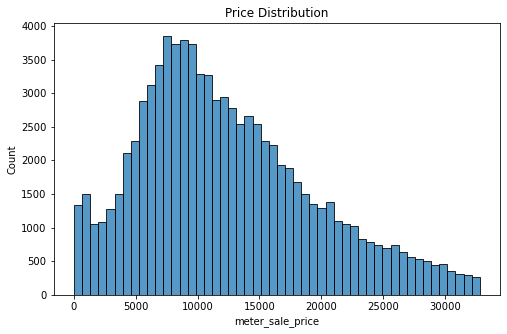

In [20]:
#Exploratory Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df_clean["meter_sale_price"], bins=50)
plt.title("Price Distribution")
plt.show()
# Price Distribution


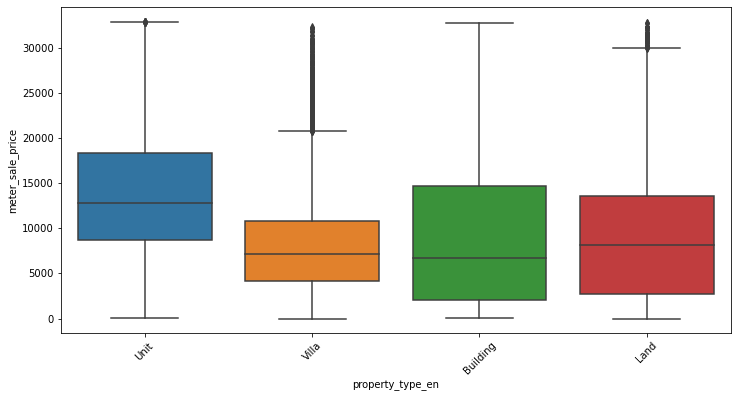

In [21]:
# Area vs Price
plt.figure(figsize=(12,6))
sns.boxplot(x="property_type_en", y="meter_sale_price", data=df_clean)
plt.xticks(rotation=45)
plt.show()

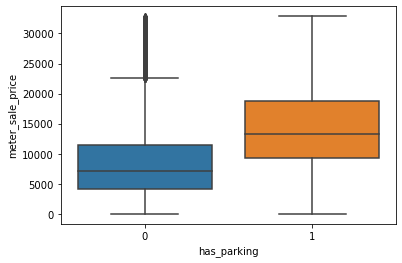

In [22]:
# Parking Impact
sns.boxplot(x="has_parking", y="meter_sale_price", data=df_clean)
plt.show()

# Feature Engineering

In [23]:
# I am creating New features.
df_clean["rooms_en"] = df_clean["rooms_en"].replace({
    "Studio": 1,
    "Unknown": 1
})

df_clean["rooms_en"] = pd.to_numeric(df_clean["rooms_en"], errors="coerce")

df_clean["area_per_room"] = df_clean["procedure_area"] / df_clean["rooms_en"]
# Property Price per Room

In [24]:
df_clean["near_metro"] = df_clean["nearest_metro_en"].apply(lambda x: 0 if x=="Unknown" else 1)
df_clean["near_mall"] = df_clean["nearest_mall_en"].apply(lambda x: 0 if x=="Unknown" else 1)
df_clean["near_landmark"] = df_clean["nearest_landmark_en"].apply(lambda x: 0 if x=="Unknown" else 1)
# Location amenities influence property value significantly.

# Train Test Split

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = df_clean.drop("meter_sale_price", axis=1)
y = df_clean["meter_sale_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [29]:
# Preprocessing Pipeline
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include="object").columns

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [31]:
#Pipeline:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# prevents data leakage

# reusable

# production ready

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [34]:
#Create a Function to Evaluate the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(n_est):
    # Model Selection

    model = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\nResults for n_estimators = {n_est}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    return pipeline

In [35]:
#Run Model with 100 Trees
pipeline_100 = evaluate_model(100)


Results for n_estimators = 100
MAE: 117.9713693107936
RMSE: 439.07653606651235
R2: 0.9961196109827927


In [36]:
# Run Model with 200 Trees

In [37]:
pipeline_200 = evaluate_model(200)


Results for n_estimators = 200
MAE: 115.4068494011163
RMSE: 437.41172632417044
R2: 0.9961489810892877


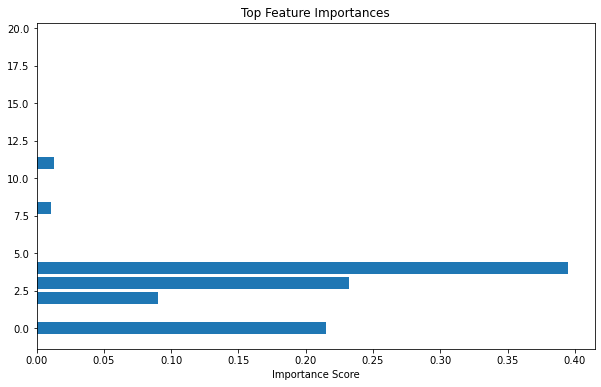

In [38]:
#Feature Importance (Using Best Model)
importances = pipeline_200.named_steps["model"].feature_importances_

plt.figure(figsize=(10,6))
plt.barh(range(len(importances[:20])), importances[:20])
plt.title("Top Feature Importances")
plt.xlabel("Importance Score")
plt.show()

In [39]:
# Comparison Table
results = []

for n in [100, 200]:

    model = RandomForestRegressor(
        n_estimators=n,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([n, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["n_estimators","MAE","RMSE","R2"])

print(results_df)

   n_estimators         MAE        RMSE        R2
0           100  117.971369  439.076536  0.996120
1           200  115.406849  437.411726  0.996149



### Model Selection Result

Two Random Forest models were evaluated using different numbers of trees (n_estimators = 100 and 200).

The model with 200 trees achieved slightly better performance across all evaluation metrics:

• Lower MAE (115 vs 117)  
• Lower RMSE (437 vs 439)  
• Slightly higher R² score (0.9961)

Increasing the number of trees improves model stability and reduces variance by averaging predictions across more decision trees.

Therefore, the Random Forest model with **200 trees** was selected as the final model.

In [40]:
df[['actual_worth','meter_sale_price']].corr()

,actual_worth,meter_sale_price
actual_worth,1.000000,0.060517
meter_sale_price,0.060517,1.000000


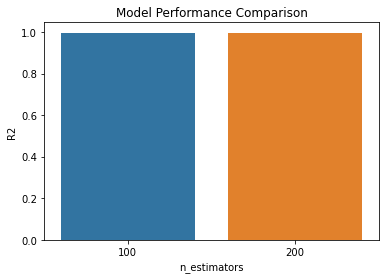

In [41]:
plt.figure(figsize=(6,4))
sns.barplot(x="n_estimators", y="R2", data=results_df)
plt.title("Model Performance Comparison")
plt.show()

# Key Insights

1. Property location plays a critical role in determining the price per square meter. Premium areas and well-known projects consistently show higher valuations.

2. Property size (procedure_area) is a strong predictor of price, indicating that larger properties tend to command higher market values.

3. Accessibility to infrastructure such as metro stations, shopping malls, and landmarks positively influences property prices.

4. Parking availability contributes to property desirability and has a moderate impact on pricing.

5. Different property types (e.g., apartments, villas, commercial properties) exhibit distinct pricing patterns across the dataset.

6. Feature importance analysis from the Random Forest model confirms that location-based features and property size are the most influential predictors in the model.